# Adaptive ETA Prediction for Inland Waterway Cargo Logistics
**Riyan Wankhede | 23BCE9287 | VIT-AP University**

End-to-end pipeline: Deep Learning ETA prediction → NLP delay severity extraction → Q-Learning adaptive adjustment

---

In [27]:
# ── Cell 0: Auto-install dependencies ──────────────────────────────────────────
import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *packages])

pip_install('torch', 'scikit-learn', 'numpy', 'pandas', 'matplotlib')
pip_install('transformers', 'sentencepiece')
print('✓ All packages ready')

✓ All packages ready


In [28]:
# ── Cell 1: Imports & Global Config ────────────────────────────────────────────
import random, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from transformers import pipeline as hf_pipeline
warnings.filterwarnings('ignore')

# ── Master config — change values here to tune the whole pipeline ──
CFG = dict(
    seed          = 42,
    n_samples     = 1_000,
    test_size     = 0.20,
    # DNN
    hidden1       = 128,
    hidden2       = 64,
    hidden3       = 32,
    drop1         = 0.30,
    drop2         = 0.30,
    drop3         = 0.15,
    lr            = 1e-3,
    epochs        = 150,
    batch_size    = 32,
    patience      = 20,
    # RL
    n_eta_bins    = 10,
    n_sev_bins    = 21,
    n_episodes    = 5_000,
    eps_start     = 1.0,
    eps_min       = 0.05,
    eps_decay     = 0.003,
    alpha         = 0.10,
    gamma_rl      = 0.90,
)

# Reproducibility
random.seed(CFG['seed'])
np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}  |  PyTorch {torch.__version__}')
print('Config loaded ✓')

Device: cpu  |  PyTorch 2.14.0+cpu
Config loaded ✓


---
## Phase 1 — Deep Learning Base ETA Predictor

In [29]:
# ── Cell 2: Dataset generation ─────────────────────────────────────────────────
def generate_dataset(n: int, seed: int) -> pd.DataFrame:
    """
    Synthetic inland waterway dataset.

    Key design choice — latent_severity:
      A hidden disruption variable (0–1, unknown to the DNN) drives 0–30% extra
      travel time.  The ML model cannot see it, so it under-predicts on high-
      severity voyages.  The NLP + RL layer is trained to correct that residual.
    """
    rng = np.random.default_rng(seed)
    records = []

    for _ in range(n):
        dist     = float(rng.uniform(50,  500))
        speed    = float(rng.uniform(5,   20))
        current  = float(rng.uniform(0,   2))
        weather  = float(rng.uniform(0,   1))
        cong     = float(rng.uniform(0,   1))

        # Base physics
        eta = (dist / max(speed - current * 0.5, 1.0)) * 60
        eta *= (1 + weather * 0.2 + cong * 0.15)

        # ── Latent disruption (invisible to DNN) ──
        lat_sev      = float(rng.uniform(0, 1))
        delay_factor = lat_sev * float(rng.uniform(0, 0.30))
        eta         *= (1 + delay_factor)
        eta         += float(rng.normal(0, 15))
        eta          = max(eta, 60.0)

        records.append(dict(
            distance         = dist,
            vessel_speed     = speed,
            river_current    = current,
            weather_severity = weather,
            port_congestion  = cong,
            latent_severity  = lat_sev,   # stored for RL matching; never fed to DNN
            actual_eta       = eta,
        ))

    return pd.DataFrame(records)


df = generate_dataset(CFG['n_samples'], CFG['seed'])
print(f'Dataset: {len(df):,} rows')
print(df[['distance','vessel_speed','river_current','weather_severity',
          'port_congestion','latent_severity','actual_eta']].describe().round(2))

df.head()

Dataset: 1,000 rows
       distance  vessel_speed  river_current  weather_severity  \
count   1000.00       1000.00        1000.00           1000.00   
mean     265.32         12.36           1.00              0.50   
std      128.04          4.37           0.58              0.29   
min       50.42          5.01           0.00              0.00   
25%      155.70          8.61           0.49              0.26   
50%      261.08         12.38           1.00              0.50   
75%      374.63         16.23           1.51              0.75   
max      499.99         19.96           2.00              1.00   

       port_congestion  latent_severity  actual_eta  
count          1000.00          1000.00     1000.00  
mean              0.49             0.52     2006.90  
std               0.29             0.29     1404.79  
min               0.00             0.00      223.77  
25%               0.23             0.27      985.58  
50%               0.48             0.52     1716.94  
75%    

,distance,vessel_speed,river_current,weather_severity,port_congestion,latent_severity,actual_eta
0,398.280222,11.583177,1.717196,0.697368,0.094177,0.975622,3138.382391
1,107.651135,11.755789,0.741596,0.926765,0.643865,0.822762,793.990847
2,299.563154,5.957259,1.655262,0.631664,0.758088,0.354526,4791.285705
3,400.272574,7.919581,0.933442,0.043804,0.154289,0.683049,3826.622209
4,196.621411,10.556896,0.939112,0.189471,0.129922,0.475705,1286.427530


In [30]:
# ── Cell 3: Preprocessing ──────────────────────────────────────────────────────
FEATURE_COLS = ['distance','vessel_speed','river_current',
                'weather_severity','port_congestion']
TARGET_COL   = 'actual_eta'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values.reshape(-1, 1)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=CFG['test_size'], random_state=CFG['seed'])

# Scalers fitted on train only → no leakage
x_scaler = StandardScaler().fit(X_tr)
y_scaler = StandardScaler().fit(y_tr)

X_tr_s = torch.tensor(x_scaler.transform(X_tr), dtype=torch.float32)
y_tr_s = torch.tensor(y_scaler.transform(y_tr),  dtype=torch.float32)
X_te_s = torch.tensor(x_scaler.transform(X_te), dtype=torch.float32)
y_te_s = torch.tensor(y_scaler.transform(y_te),  dtype=torch.float32)

# drop_last=True → prevents BatchNorm crash on 1-sample tail batch
train_loader = DataLoader(
    TensorDataset(X_tr_s, y_tr_s),
    batch_size=CFG['batch_size'], shuffle=True, drop_last=True)

print(f'Train: {len(X_tr):,}  |  Test: {len(X_te):,}')

Train: 800  |  Test: 200


In [31]:
# ── Cell 4: ETAModel definition ────────────────────────────────────────────────
class ETAModel(nn.Module):
    """Deep MLP with BatchNorm + Dropout for ETA regression."""

    def __init__(self, in_features: int, cfg: dict):
        super().__init__()
        h1, h2, h3 = cfg['hidden1'], cfg['hidden2'], cfg['hidden3']
        d1, d2, d3 = cfg['drop1'],   cfg['drop2'],   cfg['drop3']

        self.net = nn.Sequential(
            nn.Linear(in_features, h1), nn.BatchNorm1d(h1), nn.ReLU(), nn.Dropout(d1),
            nn.Linear(h1, h2),          nn.BatchNorm1d(h2), nn.ReLU(), nn.Dropout(d2),
            nn.Linear(h2, h3),          nn.BatchNorm1d(h3), nn.ReLU(), nn.Dropout(d3),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x)


model = ETAModel(len(FEATURE_COLS), CFG).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

ETAModel(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 11,585


In [32]:
# ── Cell 5: Training loop ──────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=CFG['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=8, factor=0.5)
criterion = nn.MSELoss()

train_losses, val_losses = [], []
best_val, patience_counter, best_state = np.inf, 0, None

for epoch in range(1, CFG['epochs'] + 1):
    # ── train ──
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # ── validate ──
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_te_s.to(DEVICE)), y_te_s.to(DEVICE)).item()
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # early stopping
    if val_loss < best_val:
        best_val, patience_counter = val_loss, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f'Early stop at epoch {epoch}')
            break

    if epoch % 20 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | train loss = {train_losses[-1]:.4f} | val loss= {val_loss:.4f}')

model.load_state_dict(best_state)
print('\nBest weights restored ✓')

Epoch   1 | train loss = 0.5810 | val loss= 0.2005
Epoch  20 | train loss = 0.1574 | val loss= 0.0387
Epoch  40 | train loss = 0.1232 | val loss= 0.0323
Epoch  60 | train loss = 0.1183 | val loss= 0.0210
Epoch  80 | train loss = 0.1525 | val loss= 0.0229
Early stop at epoch 83

Best weights restored ✓


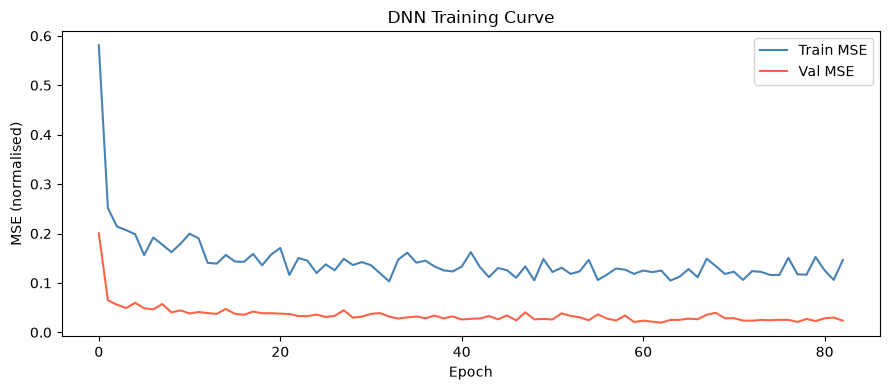

In [33]:
# ── Cell 6: Learning-curve plot ────────────────────────────────────────────────
import os
os.makedirs('figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train MSE', color='steelblue')
ax.plot(val_losses,   label='Val MSE',   color='tomato')
ax.set(xlabel='Epoch', ylabel='MSE (normalised)', title='DNN Training Curve')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_dnn_training_curve.png', dpi=180, bbox_inches='tight')
plt.show()

Base ETA  →  MAE = 137.89 min   R² = 0.9773


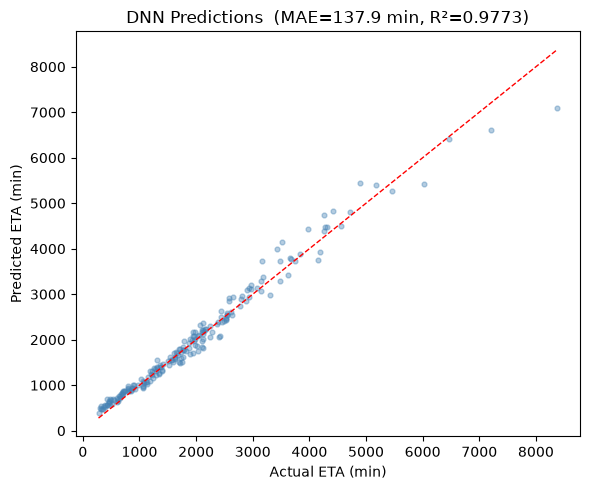


Sanity check predict_base_eta: 4479.3 min  (actual 4276.4 min)


In [34]:
# ── Cell 7: Test-set evaluation & inference helper ─────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_s = model(X_te_s.to(DEVICE)).cpu().numpy()

y_pred = y_scaler.inverse_transform(y_pred_s).flatten()
y_true = y_te.flatten()

mae_base = mean_absolute_error(y_true, y_pred)
r2_base  = r2_score(y_true, y_pred)
print(f'Base ETA  →  MAE = {mae_base:.2f} min   R² = {r2_base:.4f}')

# Scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true, y_pred, alpha=0.4, s=12, color='steelblue')
lim = [y_true.min(), y_true.max()]
ax.plot(lim, lim, 'r--', lw=1)
ax.set(xlabel='Actual ETA (min)', ylabel='Predicted ETA (min)',
       title=f'DNN Predictions  (MAE={mae_base:.1f} min, R²={r2_base:.4f})')
plt.tight_layout()
plt.savefig('figures/fig_dnn_scatter.png', dpi=180, bbox_inches='tight')
plt.show()


# ── inference helper used by RL evaluation ──────────────────────────────────
def predict_base_eta(features: list) -> float:
    """features = [distance, speed, current, weather, congestion]"""
    x = np.array(features, dtype=np.float32).reshape(1, -1)
    xs = x_scaler.transform(x)
    model.eval()
    with torch.no_grad():
        ys = model(torch.tensor(xs).to(DEVICE)).cpu().numpy()
    return float(y_scaler.inverse_transform(ys)[0, 0])

# quick sanity
sample = X_te[0].tolist()
print(f'\nSanity check predict_base_eta: {predict_base_eta(sample):.1f} min  '
      f'(actual {y_te[0,0]:.1f} min)')

---
## Phase 2 — NLP Delay Severity Extraction

In [35]:
# ── Cell 8: NLP pipeline ───────────────────────────────────────────────────────
# Step 1 — clear-negative phrase shortcut (avoids DistilBERT for obvious cases)
_CLEAR_NEGATIVE = [
    'smooth navigation', 'no issues', 'no operational issues', 'all clear',
    'no delays', 'conditions normal', 'operations normal', 'clear skies',
]

# Step 2 — domain keyword → severity weight
_KEYWORDS = {
    # High severity
    'storm': 1.00, 'hurricane': 1.00, 'flood': 0.95, 'tornado': 0.95,
    # Medium-high
    'congestion': 0.90, 'lock': 0.90, 'closure': 0.90, 'grounded': 0.90,
    'collision': 0.90, 'fire': 0.90,
    # Medium
    'fog': 0.80, 'ice': 0.80, 'snow': 0.80, 'maintenance': 0.75,
    'repair': 0.75, 'breakdown': 0.75, 'delay': 0.70, 'delayed': 0.70,
    # Lower
    'opposing current': 0.65, 'opposing': 0.65, 'headcurrent': 0.60,'headwind': 0.60, 'rain': 0.55,
    'reduced visibility': 0.55, 'overcast': 0.45, 'wind': 0.40,
    'traffic': 0.40, 'waiting': 0.35, 'queue': 0.35,
    # Very low / normal
    'minor': 0.20, 'slight': 0.20, 'smooth': 0.05, 'clear': 0.05,
}

# Step 3 — DistilBERT sentiment fallback (lazy-loaded)
_sentiment_pipe = None

def _get_sentiment_pipe():
    global _sentiment_pipe
    if _sentiment_pipe is None:
        print('Loading DistilBERT …', end=' ')
        _sentiment_pipe = hf_pipeline(
            'sentiment-analysis',
            model='distilbert-base-uncased-finetuned-sst-2-english',
            device=-1)
        print('done ✓')
    return _sentiment_pipe


def extract_delay_severity(text: str) -> float:
    """
    Hybrid 3-step NLP pipeline.

    Returns a severity score in [0, 1]:
        0.0 = no delay / perfectly smooth
        1.0 = severe delay (storm / collision / lock closure)

    Steps
    -----
    1. Clear-phrase shortcut → return 0.05 immediately.
    2. Domain keyword scan  → weighted average of matched keywords.
    3. DistilBERT fallback  → map NEGATIVE sentiment to 0.5 if no keywords found.
    """
    text_lower = text.lower()

    # ── Step 1: clear-phrase shortcut ──
    if any(phrase in text_lower for phrase in _CLEAR_NEGATIVE):
        return 0.05

    # ── Step 2: keyword scan ──
    matched = {kw: w for kw, w in _KEYWORDS.items() if kw in text_lower}
    if matched:
        severity = np.average(list(matched.values()),
                              weights=list(matched.values()))
        return float(np.clip(severity, 0.0, 1.0))

    # ── Step 3: DistilBERT fallback ──
    pipe = _get_sentiment_pipe()
    result = pipe(text[:512])[0]
    if result['label'] == 'NEGATIVE':
        return float(np.clip(result['score'] * 0.6, 0.0, 1.0))
    return float(np.clip((1.0 - result['score']) * 0.3, 0.0, 1.0))


print('NLP pipeline defined ✓')

NLP pipeline defined ✓


                                 Log text (truncated)  Severity
             Smooth navigation, no operational issues     0.050
       Overcast skies, minor headwind along the canal     0.462
    Traffic queue at lock gate — expected 20-min wait     0.662
        Fog reducing visibility; vessel speed reduced     0.800
Port congestion due to lock maintenance near terminal     0.856
    Strong opposing river current reported by captain     0.650
        Heavy fog reducing visibility along the canal     0.800
            Storm conditions delaying vessel movement     0.876


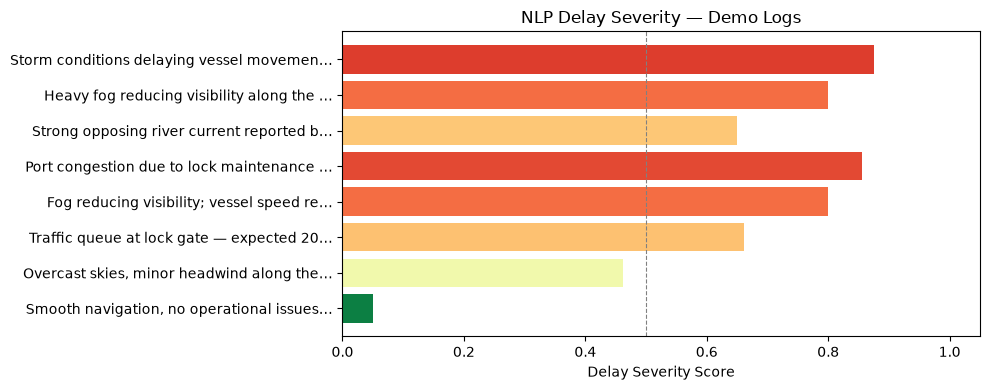

In [36]:
# ── Cell 9: NLP demo ───────────────────────────────────────────────────────────
demo_logs = [
    'Smooth navigation, no operational issues',
    'Overcast skies, minor headwind along the canal',
    'Traffic queue at lock gate — expected 20-min wait',
    'Fog reducing visibility; vessel speed reduced',
    'Port congestion due to lock maintenance near terminal',
    'Strong opposing river current reported by captain',
    'Heavy fog reducing visibility along the canal',
    'Storm conditions delaying vessel movement',
]

rows = []
for log in demo_logs:
    sev = extract_delay_severity(log)
    rows.append({'Log text (truncated)': log[:60], 'Severity': round(sev, 3)})

demo_df = pd.DataFrame(rows)
print(demo_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
labels = [r['Log text (truncated)'][:40] + '…' for r in rows]
vals   = [r['Severity'] for r in rows]
bars = ax.barh(labels, vals, color=plt.cm.RdYlGn_r(np.array(vals)))
ax.set(xlabel='Delay Severity Score', xlim=(0, 1.05),
       title='NLP Delay Severity — Demo Logs')
ax.axvline(0.5, ls='--', color='grey', lw=0.8)
plt.tight_layout()
plt.savefig('figures/fig_nlp_severity.png', dpi=180, bbox_inches='tight')
plt.show()

---
## Phase 3 — Reinforcement Learning (Q-Learning) Adaptive ETA

In [37]:
# ── Cell 10: Maritime log pool ──────────────────────────────────────────────────
MARITIME_LOG_POOL = [
    # ~0.05 – clear
    'Smooth navigation, no operational issues',
    'All clear — no delays expected along the route',
    'Conditions normal, vessel on schedule',
    # ~0.35–0.50 – minor
    'Overcast skies with slight headwind, minor slowdown',
    'Light rain along northern section, visibility adequate',
    'Waiting at staging area — minor queue at lock',
    'Traffic queue at lock gate — expected 20-min wait',
    'Opposing current detected; adjusting vessel speed',
    # ~0.55–0.70 – moderate
    'Heavy rain reducing speed near km 240',
    'Reduced visibility due to haze; proceeding with caution',
    'Strong opposing river current reported by captain',
    'Delay reported at intermediate lock — backup queue forming',
    'Maintenance crew working on lock gate; 45-minute expected wait',
    # ~0.75–0.90 – severe
    'Heavy fog reducing visibility along the canal',
    'Port congestion due to lock maintenance near terminal',
    'Lock closure scheduled for maintenance — 2-hour hold',
    'Breakdown reported — vessel stationary awaiting repair crew',
    # ~0.90–1.00 – extreme
    'Storm conditions delaying vessel movement',
    'Severe storm warnings issued — all vessels holding position',
    'Flooding near terminal; operations suspended until further notice',
]

# Pre-compute severity scores once
pool_scores = np.array([extract_delay_severity(log) for log in MARITIME_LOG_POOL])
print('Log pool severity scores:')
for log, sev in zip(MARITIME_LOG_POOL, pool_scores):
    print(f'  {sev:.3f}  {log[:70]}')

Log pool severity scores:
  0.050  Smooth navigation, no operational issues
  0.050  All clear — no delays expected along the route
  0.050  Conditions normal, vessel on schedule
  0.434  Overcast skies with slight headwind, minor slowdown
  0.550  Light rain along northern section, visibility adequate
  0.608  Waiting at staging area — minor queue at lock
  0.662  Traffic queue at lock gate — expected 20-min wait
  0.650  Opposing current detected; adjusting vessel speed
  0.550  Heavy rain reducing speed near km 240
  0.550  Reduced visibility due to haze; proceeding with caution
  0.650  Strong opposing river current reported by captain
  0.729  Delay reported at intermediate lock — backup queue forming
  0.832  Maintenance crew working on lock gate; 45-minute expected wait
  0.800  Heavy fog reducing visibility along the canal
  0.856  Port congestion due to lock maintenance near terminal
  0.856  Lock closure scheduled for maintenance — 2-hour hold
  0.674  Breakdown reported — ve

In [38]:
# ── Cell 11: RL Environment ─────────────────────────────────────────────────────
class ETAEnvironment:
    """
    Q-Learning environment for adaptive ETA adjustment.

    State space (110 states)
    ------------------------
    Normalised ETA bucket  × delay severity bucket
        10 ETA bins  ×  11 severity bins  = 110 states

    Action space (5 actions)
    -------------------------
    Proportional adjustments as a fraction of base ETA:
        [0%, 2%, 5%, 10%, 20%]
    Proportional fractions scale automatically with voyage length,
    avoiding the fixed 30-min cap that is negligible on long voyages.

    Reward
    ------
    Normalised improvement:  r = (|base_err| - |adj_err|) / base_eta
    Range ≈ [-1, +1].  Positive when adjustment reduces error.
    """

    ACTION_FRACTIONS = [0.00, 0.02, 0.05, 0.10, 0.20]

    def __init__(self, dataset: pd.DataFrame, cfg: dict):
        self.df        = dataset.reset_index(drop=True)
        self.n_eta     = cfg['n_eta_bins']
        self.n_sev     = cfg['n_sev_bins']
        self.n_actions = len(self.ACTION_FRACTIONS)

        # ETA percentiles for normalised binning
        self._eta_min = self.df['actual_eta'].quantile(0.01)
        self._eta_max = self.df['actual_eta'].quantile(0.99)

        self._row        = None
        self._base_eta   = None
        self._actual_eta = None
        self._severity   = None

    # ── helpers ────────────────────────────────────────────────────────────────
    def _eta_bucket(self, eta: float) -> int:
        norm = (eta - self._eta_min) / max(self._eta_max - self._eta_min, 1.0)
        return int(np.clip(norm * self.n_eta, 0, self.n_eta - 1))

    def _sev_bucket(self, sev: float) -> int:
        return int(np.clip(sev * (self.n_sev - 1), 0, self.n_sev - 1))

    def _state(self) -> tuple:
        return (self._eta_bucket(self._base_eta),
                self._sev_bucket(self._severity))

    # ── gym-style API ─────────────────────────────────────────────────────────
    def reset(self) -> tuple:
        """Sample a random voyage and pick a severity-matched log."""
        self._row        = self.df.sample(1).iloc[0]
        self._actual_eta = float(self._row['actual_eta'])
        lat_sev          = float(self._row['latent_severity'])

        # Pick the log whose NLP score is closest to the latent severity
        closest_idx    = int(np.argmin(np.abs(pool_scores - lat_sev)))
        self._severity = float(pool_scores[closest_idx])

        features       = [self._row[c] for c in FEATURE_COLS]
        self._base_eta = predict_base_eta(features)

        return self._state()

    def step(self, action: int):
        """Apply action, compute reward, return (next_state, reward, done)."""
        frac         = self.ACTION_FRACTIONS[action]
        adjusted_eta = self._base_eta * (1.0 + frac)

        base_err  = abs(self._base_eta   - self._actual_eta)
        adj_err   = abs(adjusted_eta     - self._actual_eta)
        reward    = (base_err - adj_err) / max(self._base_eta, 1.0)

        return self._state(), float(reward), True   # episodic

    # ── property shortcuts ─────────────────────────────────────────────────────
    @property
    def base_eta(self):    return self._base_eta
    @property
    def actual_eta(self):  return self._actual_eta
    @property
    def severity(self):    return self._severity


env = ETAEnvironment(df, CFG)
print(f'Environment ready — {env.n_actions} actions, {env.n_eta * env.n_sev} states')
print(f'Action fractions: {ETAEnvironment.ACTION_FRACTIONS}')

Environment ready — 5 actions, 210 states
Action fractions: [0.0, 0.02, 0.05, 0.1, 0.2]


In [39]:
# ── Cell 12: Q-Learning Agent ───────────────────────────────────────────────────
class QLearningAgent:
    """
    Tabular Q-Learning agent with exponential epsilon-greedy decay.

    Q-table shape: (n_eta_bins, n_sev_bins, n_actions)
    Initialised to 0.01 (optimistic) to encourage early exploration of
    all actions before exploitation begins.
    """

    def __init__(self, n_eta: int, n_sev: int, n_actions: int, cfg: dict):
        self.n_actions = n_actions
        self.alpha     = cfg['alpha']
        self.gamma     = cfg['gamma_rl']
        self.eps       = cfg['eps_start']
        self.eps_min   = cfg['eps_min']
        self.eps_decay = cfg['eps_decay']

        # Optimistic initialisation → each state-action pair starts at 0.01
        self.Q = np.full((n_eta, n_sev, n_actions), 0.01)

    def select_action(self, state: tuple) -> int:
        if random.random() < self.eps:
            return random.randrange(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def update(self, state: tuple, action: int,
               reward: float, next_state: tuple) -> None:
        current_q  = self.Q[state][action]
        max_next_q = np.max(self.Q[next_state])
        td_target  = reward + self.gamma * max_next_q
        self.Q[state][action] += self.alpha * (td_target - current_q)

    def decay_epsilon(self, episode: int) -> None:
        self.eps = self.eps_min + (CFG['eps_start'] - self.eps_min) * \
                   math.exp(-self.eps_decay * episode)

    def best_action(self, state: tuple) -> int:
        return int(np.argmax(self.Q[state]))

    def q_stats(self) -> dict:
        populated = np.count_nonzero(np.any(self.Q != 0.01, axis=-1))
        return dict(populated_states=int(populated),
                    q_max=float(self.Q.max()),
                    q_min=float(self.Q.min()),
                    q_mean=float(self.Q.mean()))


agent = QLearningAgent(CFG['n_eta_bins'], CFG['n_sev_bins'],
                       len(ETAEnvironment.ACTION_FRACTIONS), CFG)
print('Agent created — Q-table shape:', agent.Q.shape)

Agent created — Q-table shape: (10, 21, 5)


In [40]:
# ── Cell 13: Training loop ──────────────────────────────────────────────────────
episode_rewards   = []
rolling_window    = 200

for ep in range(1, CFG['n_episodes'] + 1):
    state  = env.reset()
    action = agent.select_action(state)
    next_state, reward, _ = env.step(action)
    agent.update(state, action, reward, next_state)
    agent.decay_epsilon(ep)
    episode_rewards.append(reward)

    if ep % 1000 == 0:
        recent_mean = np.mean(episode_rewards[-rolling_window:])
        stats = agent.q_stats()
        print(f'Ep {ep:5d} | ε={agent.eps:.4f} | '
              f'avg_reward={recent_mean:+.4f} | '
              f'states={stats["populated_states"]} | '
              f'Q_max={stats["q_max"]:+.4f}')

print('\nTraining complete ✓')
print(agent.q_stats())

Ep  1000 | ε=0.0973 | avg_reward=-0.0071 | states=81 | Q_max=+0.0626
Ep  2000 | ε=0.0524 | avg_reward=-0.0045 | states=83 | Q_max=+0.0607
Ep  3000 | ε=0.0501 | avg_reward=-0.0047 | states=83 | Q_max=+0.0825
Ep  4000 | ε=0.0500 | avg_reward=+0.0007 | states=85 | Q_max=+0.1099
Ep  5000 | ε=0.0500 | avg_reward=-0.0012 | states=85 | Q_max=+0.1253

Training complete ✓
{'populated_states': 85, 'q_max': 0.1253433453651585, 'q_min': -0.11932075599079177, 'q_mean': 0.006896966989342628}


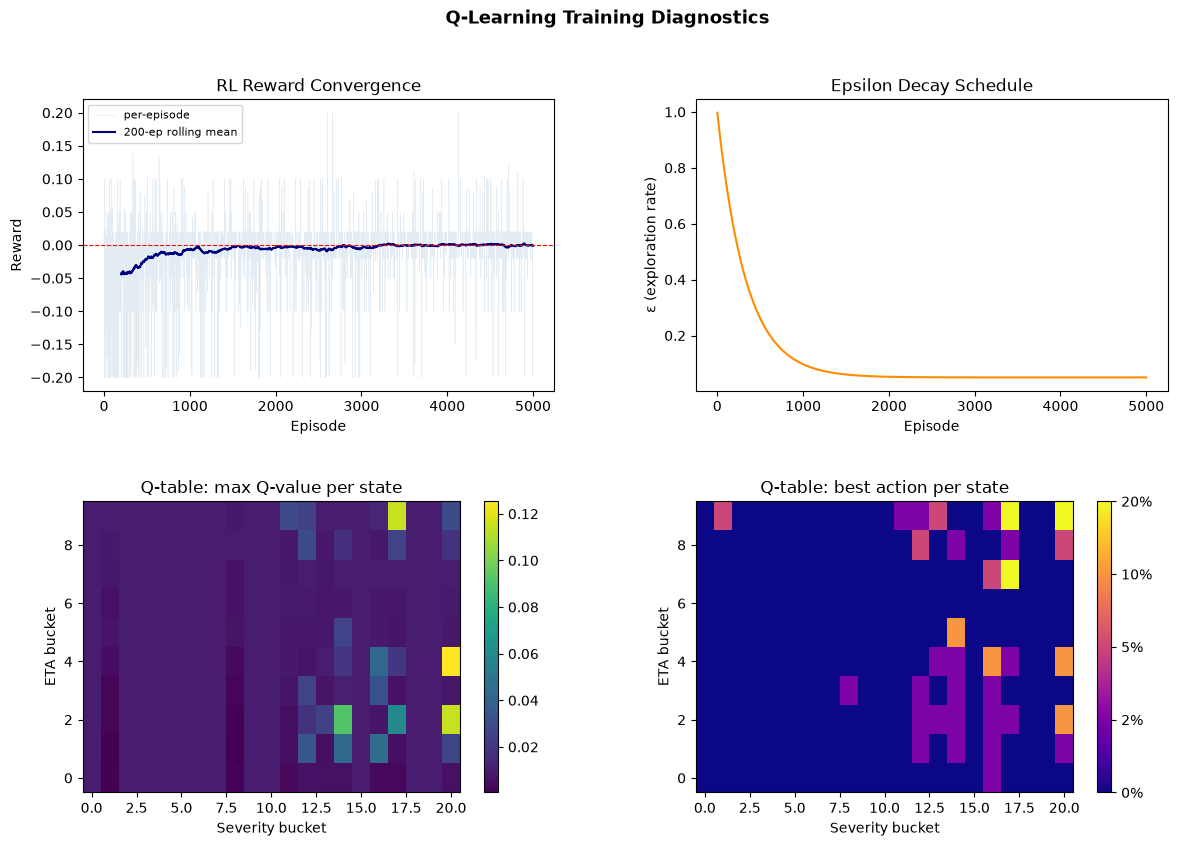

In [41]:
# ── Cell 14: 4-panel training diagnostics ──────────────────────────────────────
rewards_arr = np.array(episode_rewards)
roll        = pd.Series(rewards_arr).rolling(rolling_window).mean().values
eps_trace   = [CFG['eps_min'] + (CFG['eps_start'] - CFG['eps_min']) *
               math.exp(-CFG['eps_decay'] * t)
               for t in range(1, CFG['n_episodes'] + 1)]

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

# 1 — raw + rolling reward
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(rewards_arr, alpha=0.15, color='steelblue', lw=0.4, label='per-episode')
ax1.plot(roll, color='navy', lw=1.5, label=f'{rolling_window}-ep rolling mean')
ax1.axhline(0, color='red', lw=0.8, ls='--')
ax1.set(xlabel='Episode', ylabel='Reward', title='RL Reward Convergence')
ax1.legend(fontsize=8)

# 2 — epsilon decay
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(eps_trace, color='darkorange')
ax2.set(xlabel='Episode', ylabel='ε (exploration rate)',
        title='Epsilon Decay Schedule')

# 3 — Q-value heatmap (best action value per state)
ax3 = fig.add_subplot(gs[1, 0])
q_best = agent.Q.max(axis=-1)  # shape (n_eta, n_sev)
im     = ax3.imshow(q_best, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(im, ax=ax3)
ax3.set(xlabel='Severity bucket', ylabel='ETA bucket',
        title='Q-table: max Q-value per state')

# 4 — best action heatmap
ax4 = fig.add_subplot(gs[1, 1])
q_act = agent.Q.argmax(axis=-1)
im2   = ax4.imshow(q_act, aspect='auto', cmap='plasma', origin='lower',
                   vmin=0, vmax=len(ETAEnvironment.ACTION_FRACTIONS)-1)
cbar  = plt.colorbar(im2, ax=ax4, ticks=range(len(ETAEnvironment.ACTION_FRACTIONS)))
cbar.set_ticklabels([f'{int(f*100)}%' for f in ETAEnvironment.ACTION_FRACTIONS])
ax4.set(xlabel='Severity bucket', ylabel='ETA bucket',
        title='Q-table: best action per state')

plt.suptitle('Q-Learning Training Diagnostics', fontsize=13, fontweight='bold')
plt.savefig('figures/fig_rl_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()

In [42]:
# ── Cell 15: Greedy evaluation on test set ──────────────────────────────────────
results = []

for i in range(len(X_te)):
    features     = X_te[i].tolist()
    actual_eta   = float(y_te[i, 0])
    base_eta     = predict_base_eta(features)

    # Severity-matched single log per voyage
    residual     = max(actual_eta - base_eta, 0.0)
    implied_sev  = float(np.clip(residual / (base_eta + 1e-8), 0.0, 1.0))
    closest_idx  = int(np.argmin(np.abs(pool_scores - implied_sev)))
    severity     = float(pool_scores[closest_idx])

    eta_b        = env._eta_bucket(base_eta)
    sev_b        = env._sev_bucket(severity)
    state        = (eta_b, sev_b)

    best_act     = agent.best_action(state)
    frac         = ETAEnvironment.ACTION_FRACTIONS[best_act]
    adj_eta      = base_eta * (1.0 + frac)

    results.append(dict(
        actual_eta   = actual_eta,
        base_eta     = base_eta,
        adj_eta      = adj_eta,
        severity     = severity,
        action_frac  = frac,
    ))

res_df = pd.DataFrame(results)

mae_base_eval = mean_absolute_error(res_df['actual_eta'], res_df['base_eta'])
mae_adap_eval = mean_absolute_error(res_df['actual_eta'], res_df['adj_eta'])
pct_improve   = (mae_base_eval - mae_adap_eval) / mae_base_eval * 100

print('=' * 55)
print(f'  Base ETA MAE      : {mae_base_eval:8.2f} min')
print(f'  Adaptive ETA MAE  : {mae_adap_eval:8.2f} min')
print(f'  Improvement       : {pct_improve:+7.2f} %')
print('=' * 55)

  Base ETA MAE      :   137.89 min
  Adaptive ETA MAE  :   135.61 min
  Improvement       :   +1.65 %


       sev_band     n  MAE_base  MAE_adaptive  Δ MAE  Δ %
   Low (0–0.25) 48.00    159.57        159.57   0.00 0.00
 Med (0.25–0.5) 44.00    118.52        111.00   7.52 6.34
High (0.5–0.75) 55.00    126.37        124.11   2.26 1.79
 Ext (0.75–1.0) 53.00    146.27        146.27   0.00 0.00


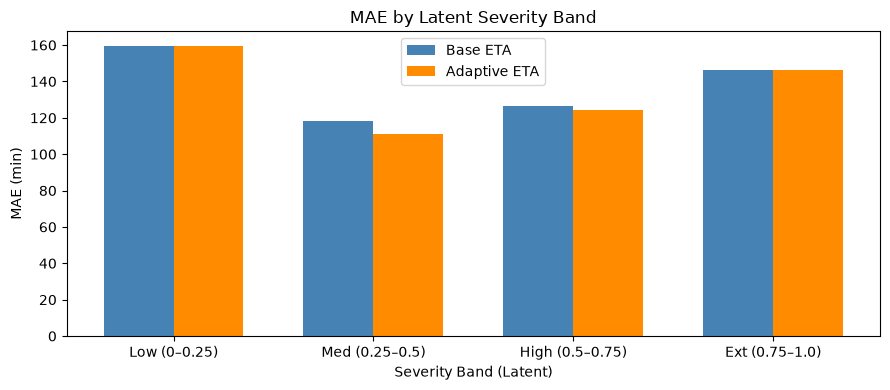

In [43]:
# ── Cell 16: Per-severity breakdown ────────────────────────────────────────────
# Recover test indices with the same seed used during preprocessing
idx = np.arange(len(df))
_, te_idx = train_test_split(idx, test_size=CFG['test_size'], random_state=CFG['seed'])
res_df['latent_severity'] = df.loc[te_idx, 'latent_severity'].values

bins   = [0.0, 0.25, 0.50, 0.75, 1.01]
labels = ['Low (0–0.25)', 'Med (0.25–0.5)',
          'High (0.5–0.75)', 'Ext (0.75–1.0)']
res_df['sev_band'] = pd.cut(res_df['latent_severity'], bins=bins, labels=labels)

breakdown = res_df.groupby('sev_band', observed=True).apply(
    lambda g: pd.Series({
        'n'           : len(g),
        'MAE_base'    : mean_absolute_error(g['actual_eta'], g['base_eta']),
        'MAE_adaptive': mean_absolute_error(g['actual_eta'], g['adj_eta']),
    })
).reset_index()
breakdown['Δ MAE'] = breakdown['MAE_base'] - breakdown['MAE_adaptive']
breakdown['Δ %']   = breakdown['Δ MAE'] / breakdown['MAE_base'] * 100

print(breakdown.to_string(index=False, float_format='%.2f'))

# Grouped bar chart
x = np.arange(len(breakdown))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, breakdown['MAE_base'],     w, label='Base ETA',     color='steelblue')
ax.bar(x + w/2, breakdown['MAE_adaptive'], w, label='Adaptive ETA', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(breakdown['sev_band'])
ax.set(xlabel='Severity Band (Latent)', ylabel='MAE (min)',
       title='MAE by Latent Severity Band')
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig_per_severity.png', dpi=180, bbox_inches='tight')
plt.show()


  FINAL RESULTS SUMMARY
                   System MAE (min)     R² Improvement
             DNN Base ETA    137.89 0.9773           —
DNN + NLP + RL (Adaptive)    135.61 0.9801      +1.65%


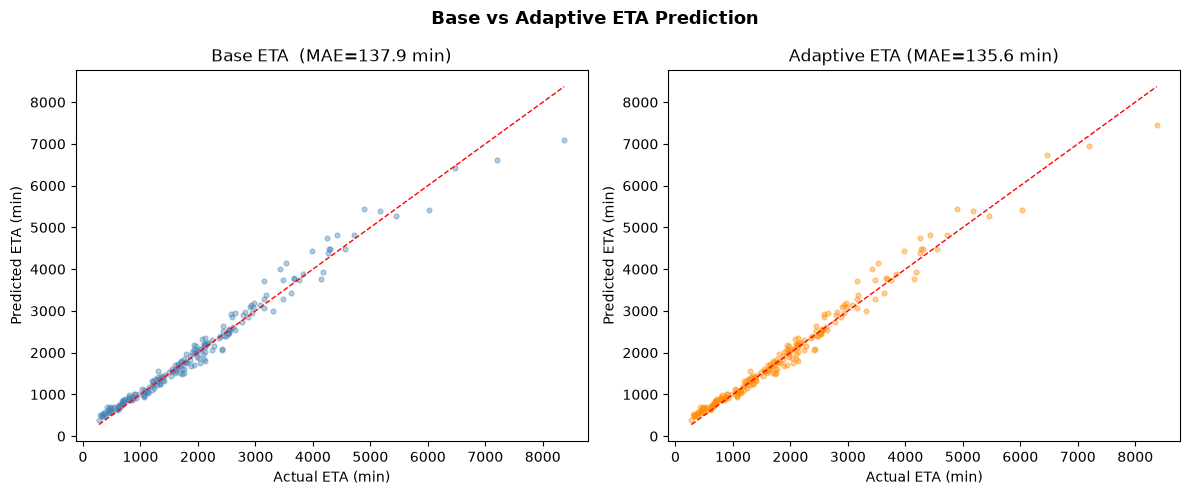


✅ All figures saved to figures/ folder


In [44]:
# ── Cell 17: Final summary ──────────────────────────────────────────────────────
r2_adap = r2_score(res_df['actual_eta'], res_df['adj_eta'])
r2_base_eval = r2_score(res_df['actual_eta'], res_df['base_eta'])

summary = pd.DataFrame([
    {'System'  : 'DNN Base ETA',
     'MAE (min)': f'{mae_base_eval:.2f}',
     'R²'       : f'{r2_base_eval:.4f}',
     'Improvement': '—'},
    {'System'  : 'DNN + NLP + RL (Adaptive)',
     'MAE (min)': f'{mae_adap_eval:.2f}',
     'R²'       : f'{r2_adap:.4f}',
     'Improvement': f'{pct_improve:+.2f}%'},
])
print('\n' + '=' * 60)
print('  FINAL RESULTS SUMMARY')
print('=' * 60)
print(summary.to_string(index=False))
print('=' * 60)

# Side-by-side scatter comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, label, color in [
    (ax1, res_df['base_eta'],  f'Base ETA  (MAE={mae_base_eval:.1f} min)', 'steelblue'),
    (ax2, res_df['adj_eta'],   f'Adaptive ETA (MAE={mae_adap_eval:.1f} min)', 'darkorange'),
]:
    ax.scatter(res_df['actual_eta'], pred, alpha=0.4, s=12, color=color)
    lim = [res_df['actual_eta'].min(), res_df['actual_eta'].max()]
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set(xlabel='Actual ETA (min)', ylabel='Predicted ETA (min)', title=label)
plt.suptitle('Base vs Adaptive ETA Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/fig_base_vs_adaptive.png', dpi=180, bbox_inches='tight')
plt.show()

print('\n✅ All figures saved to figures/ folder')

---
## Interactive Single-Voyage Prediction
Edit the **VOYAGE** dict and the **LOG** string below, then run the cell.

In [45]:
# ── Cell 18: Interactive single-voyage prediction ──────────────────────────────
VOYAGE = dict(distance=450, vessel_speed=8, river_current=1.8,
              weather_severity=0.95, port_congestion=0.7)
LOG = 'Storm conditions delaying vessel movement'

features   = list(VOYAGE.values())
base_eta   = predict_base_eta(features)
severity   = extract_delay_severity(LOG)
state      = (env._eta_bucket(base_eta), env._sev_bucket(severity))
frac       = ETAEnvironment.ACTION_FRACTIONS[agent.best_action(state)]
adj_eta    = base_eta * (1.0 + frac)

print('ADAPTIVE ETA PREDICTION RESULT')
print('─' * 48)
for k, v in VOYAGE.items():
    print(f'  {k:<22}: {v}')
print('─' * 48)
print(f'  {"Operational log":<22}: {LOG}')
print(f'  {"NLP severity":<22}: {severity:.3f}')
print('─' * 48)
print(f'  {"Base ETA":<22}: {base_eta:.1f} min')
print(f'  {"RL adjustment":<22}: +{frac*100:.0f}%  ({base_eta*frac:.1f} min added)')
print(f'  {"Adaptive ETA (FINAL)":<22}: {adj_eta:.1f} min')
print('─' * 48)


ADAPTIVE ETA PREDICTION RESULT
────────────────────────────────────────────────
  distance              : 450
  vessel_speed          : 8
  river_current         : 1.8
  weather_severity      : 0.95
  port_congestion       : 0.7
────────────────────────────────────────────────
  Operational log       : Storm conditions delaying vessel movement
  NLP severity          : 0.876
────────────────────────────────────────────────
  Base ETA              : 5846.5 min
  RL adjustment         : +2%  (116.9 min added)
  Adaptive ETA (FINAL)  : 5963.4 min
────────────────────────────────────────────────


---
## Load Saved Models (for inference-only deployments)
Run this section in a fresh kernel after training to restore the pipeline without retraining.


In [46]:
# ── Cell 19: Load saved models ─────────────────────────────────────────────────
import pickle, torch, numpy as np
from sklearn.preprocessing import StandardScaler

# -- Restore DNN --
scalers  = torch.load('models/scalers.pt', weights_only=False)
x_scaler = scalers['x_scaler']
y_scaler = scalers['y_scaler']

# Re-define ETAModel class before loading weights (or import from a module)
loaded_model = ETAModel(5, CFG).to(DEVICE)
loaded_model.load_state_dict(torch.load('models/eta_dnn.pt',
                                        map_location=DEVICE, weights_only=True))
loaded_model.eval()

# -- Restore Q-table --
with open('models/q_table.pkl', 'rb') as f:
    loaded_Q = pickle.load(f)

print('Models restored ✓')
print(f'  DNN params : {sum(p.numel() for p in loaded_model.parameters()):,}')
print(f'  Q-table    : {loaded_Q.shape}')


Models restored ✓
  DNN params : 11,585
  Q-table    : (10, 21, 5)
